# Notebook 4: Activation Functions



## Why do we need Activation Functions at all?

**Explanation:**
In math, the sum of multiple linear functions is still a linear function. If we didn't have activation functions, stacking 100 layers of neurons would be the same as having just 1 layer. 

Activation functions introduce **Non-Linearity**. This allows the network to "bend" its decision boundary to fit complex shapes, like circles, spirals, or human faces.

## 1. Sigmoid Activation

**Formula:** $\sigma(z) = \frac{1}{1 + e^{-z}}$
**Range:** $(0, 1)$

**Pros:**
- Perfect for binary classification (outputs a probability).
- Smooth gradient.

**Cons:**
- **Vanishing Gradient Problem:** For very high or very low values of $z$, the slope (gradient) becomes almost zero. This means the model stops learning.
- Not zero-centered.

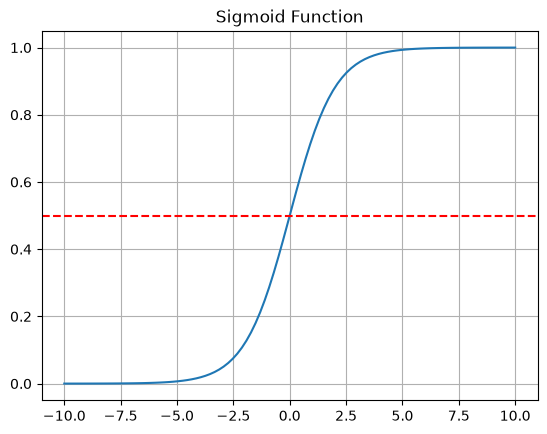

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.title("Sigmoid Function")
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--')
plt.show()

## 2. Tanh (Hyperbolic Tangent)

**Formula:** $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$
**Range:** $(-1, 1)$

**Pros:**
- Zero-centered (outputs average to 0), which makes optimization faster than Sigmoid.

**Cons:**
- Still suffers from the **Vanishing Gradient** problem at the extremes.

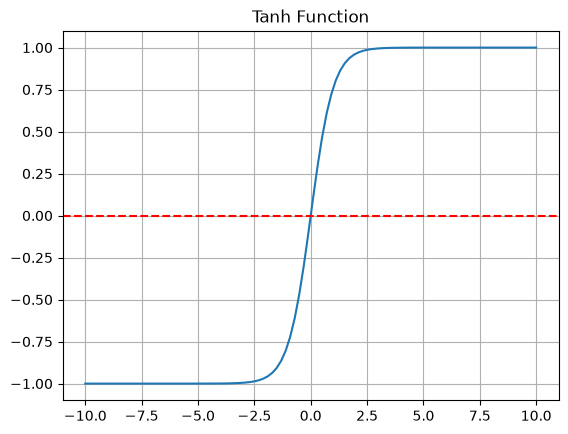

In [2]:
def tanh(z):
    return np.tanh(z)

plt.plot(z, tanh(z))
plt.title("Tanh Function")
plt.grid(True)
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

## 3. ReLU (Rectified Linear Unit)

**Formula:** $f(z) = \max(0, z)$
**Range:** $[0, \infty)$

**Why it became popular:**
ReLU is the default choice for hidden layers in almost all deep networks today.
1. **Computational Efficiency:** It's just a `max(0, z)` operation—much faster than calculating exponents ($e^z$).
2. **Solves Vanishing Gradient:** For all $z > 0$, the gradient is always 1. It doesn't "flatten out" like Sigmoid.

**The "Dying ReLU" Problem:**
If a neuron's weights are updated such that it always outputs $z < 0$, it will always output 0. The gradient becomes 0, and the neuron "dies"—it will never update its weights again.

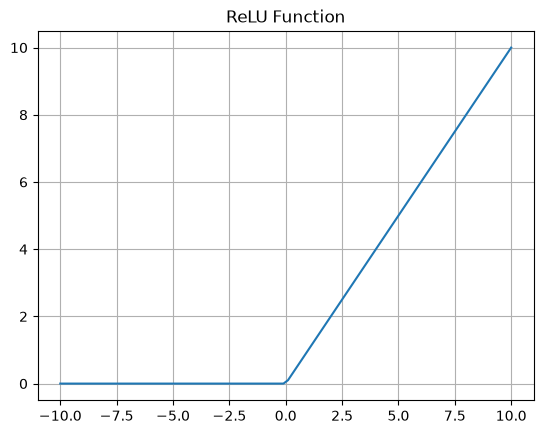

In [3]:
def relu(z):
    return np.maximum(0, z)

plt.plot(z, relu(z))
plt.title("ReLU Function")
plt.grid(True)
plt.show()

## 4. Leaky ReLU

**Purpose:**
To fix the "Dying ReLU" problem. Instead of a flat 0 for $z < 0$, it allows a tiny slope (e.g., $0.01z$).

**Difference from ReLU:**
It ensures that every neuron, even those with negative inputs, still has a small gradient, allowing them to eventually "wake up" and learn.

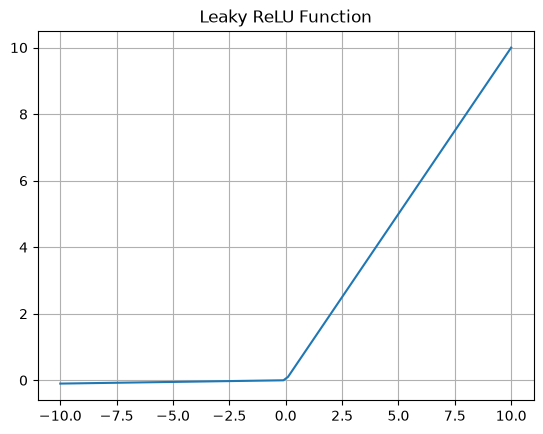

In [4]:
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

plt.plot(z, leaky_relu(z))
plt.title("Leaky ReLU Function")
plt.grid(True)
plt.show()

## 5. Softmax

**Purpose:**
Unlike the others, Softmax is used almost exclusively in the **Output Layer** for multi-class classification.

**Interpretation:**
It takes a vector of raw scores (logits) and transforms them into a **probability distribution**. The sum of all outputs is always exactly 1.0.
- If you have 3 classes (Cat, Dog, Bird), Softmax might output `[0.7, 0.2, 0.1]`, meaning there is a 70% chance the image is a Cat.

In [5]:
def softmax(z):
    exp_z = np.exp(z - np.max(z)) # Subtract max for numerical stability
    return exp_z / exp_z.sum()

logits = np.array([2.0, 1.0, 0.1])
probs = softmax(logits)

print(f"Raw scores (logits): {logits}")
print(f"Probabilities: {probs}")
print(f"Sum of probabilities: {np.sum(probs)}")

Raw scores (logits): [2.  1.  0.1]
Probabilities: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0


## Summary Comparison

| Function | Range | Use Case | Key Note |
| :--- | :--- | :--- | :--- |
| **Sigmoid** | $(0, 1)$ | Binary Output | Vanishing Gradient |
| **Tanh** | $(-1, 1)$ | Hidden Layers | Zero-centered |
| **ReLU** | $[0, \infty)$ | Hidden Layers | Fast, Standard choice |
| **Leaky ReLU** | $(-\infty, \infty)$ | Hidden Layers | Prevents Dying ReLU |
| **Softmax** | $(0, 1)$ | Multi-class Output | Probabilities sum to 1 |